# **Demo 03: Building a Reactive Agent Workflow with LangGraph and Tavily**

**Objective:** To demonstrate how to build a reactive AI agent using the LangGraph framework integrated with LangChain’s Tavily search tool. This demo guides learners through creating a react-style agent using create_react_agent(), connecting it to a real-time web search function, and invoking the agent to respond dynamically to user queries. The focus is on showcasing how LangGraph enables modular, tool-enhanced agent workflows for tasks that require external information retrieval and context-aware decision-making

**Prerequisites:** Tavily key, OpenAI API key 

**Tools required:** Python

**Scenario:** : A product lead at a fintech startup wants to monitor global developments in real-time fraud detection methods for UPI systems. The manual process of tracking cybersecurity advancements and regulatory changes is inefficient and prone to oversight. The goal is to automate this workflow using LangGraph, where an agent uses a search tool to gather the latest research and another agent validates and summarizes the findings for internal teams.

In [1]:
# Step 1: Install required libraries
%pip install langgraph langchain-openai langchain-tavily tavily-python python-dotenv

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\AgrawalN\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import os

# Manually read the .env file to avoid path issues with load_dotenv
_env_file = r"c:\Nikhil\Work_Related\AI\MSAGI\AI\5-Multi-Agent Ecosystem 1\Demos_updated\Lesson_02\Demo_3\.env"
with open(_env_file, encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line and not line.startswith("#") and "=" in line:
            key, value = line.split("=", 1)
            os.environ[key.strip()] = value.strip()

# Verify keys are loaded (prints True/False, not the actual keys)
print("OPENAI_API_KEY loaded:", bool(os.environ.get("OPENAI_API_KEY")))
print("TAVILY_API_KEY loaded:", bool(os.environ.get("TAVILY_API_KEY")))
print("GROQ_API_KEY loaded:", bool(os.environ.get("GROQ_API_KEY")))
print("HF_API_KEY loaded:", bool(os.environ.get("HF_API_KEY")))

OPENAI_API_KEY loaded: True
TAVILY_API_KEY loaded: True
GROQ_API_KEY loaded: True
HF_API_KEY loaded: True


In [ ]:
# Create the LLM object

# ==============================================================================
# LLM Provider Selection
# This demo supports three interchangeable LLM backends. All expose an
# OpenAI-compatible chat-completions endpoint, so LangGraph can interact with them
# through ChatOpenAI without any code changes beyond swapping the config below.
#
# Change LLM_PROVIDER to "huggingface", "groq", "DeepSeek", or "azure" to switch providers.
# ==============================================================================
from langchain_openai import ChatOpenAI, AzureChatOpenAI

LLM_PROVIDER = "groq"  # Options: "huggingface", "groq", "azure", "DeepSeek"

if LLM_PROVIDER == "huggingface":
    hf_key = os.getenv("HF_API_KEY")
    if not hf_key:
        raise ValueError("HF_API_KEY not found in environment variables.")
    llm = ChatOpenAI(
        model="Qwen/Qwen2.5-7B-Instruct",
        api_key=hf_key,
        base_url="https://router.huggingface.co/v1",
        temperature=0.5,
    )
elif LLM_PROVIDER == "groq":
    groq_key = os.getenv("GROQ_API_KEY")
    if not groq_key:
        raise ValueError("GROQ_API_KEY not found in environment variables. Add it to your .env file.")
    llm = ChatOpenAI(
        model="llama-3.3-70b-versatile",
        api_key=groq_key,
        base_url="https://api.groq.com/openai/v1",
        temperature=0.5,
    )
elif LLM_PROVIDER == "azure":
    llm = AzureChatOpenAI(
        azure_deployment=os.getenv("AZURE_OPENAI_DEPLOYMENT"),
        api_key=os.getenv("AZURE_OPENAI_API_KEY"),
        azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
        api_version=os.getenv("AZURE_OPENAI_API_VERSION"),
        temperature=0.5,
    )
elif LLM_PROVIDER == "DeepSeek":
    hf_key = os.getenv("HF_API_KEY")
    if not hf_key:
        raise ValueError("HF_API_KEY not found in environment variables.")
    llm = ChatOpenAI(
        model="deepseek-ai/DeepSeek-V4-Pro:novita",
        api_key=hf_key,
        base_url="https://router.huggingface.co/v1",
        temperature=0.5,
    )
else:
    raise ValueError(f"Unknown LLM_PROVIDER: {LLM_PROVIDER}. Use 'huggingface', 'groq', 'DeepSeek', or 'azure'.")

print(f"LLM configured: {LLM_PROVIDER}")

LLM configured: DeepSeek


In [4]:
# Build Tavily Search Tool

from langchain_tavily import TavilySearch
from langchain.tools import tool

@tool
def search_tool(query: str):
    """Use this tool to search the web via Tavily API"""
    tavily_search_tool = TavilySearch(max_results=3)
    result = tavily_search_tool.invoke(query)
    return result


In [5]:
# Create a Reactive Agent with LangGraph and attach the Tavily tool

from langchain.agents import create_agent

agent = create_agent(model=llm, tools=[search_tool])

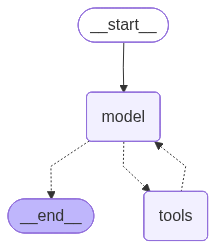

In [6]:
# Visualize the agent graph
agent

In [7]:
# Execute the agent WITH the search tool
state = agent.invoke({
    "messages": [
        {"role": "user", "content": "What are the latest fraud detection methods in UPI systems?"}
    ]
})

print("\n[With Tavily Search Tool]:\n", state)


BadRequestError: Error code: 400 - {'message': 'invalid request error trace_id: 4791e564ca146a35330ef1cafe5994f6', 'type': 'invalid_request_error'}

In [ ]:
# Execute the agent WITHOUT the search tool (pure LLM reasoning)
state = agent.invoke({
    "messages": [
        {"role": "user", "content": "What is 2 + 3?"}
    ]
})

print("\n[Without Tool]:\n", state)


#### By following these steps, you have successfully built a reactive AI agent with LangGraph, integrated LangChain’s Tavily search, created it via create_react_agent(), connected real-time web search, and invoked it to respond dynamically to user queries—showcasing LangGraph’s modular, tool-enhanced workflows for external retrieval and context-aware decision-making.